In [17]:
from xcube.core.store import new_data_store
from xcube_resampling.gridmapping import GridMapping
from xcube_resampling import resample_in_space

In [3]:
store = new_data_store("cciodp")

In [6]:
ds = store.open_data(
    "esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-platform.MERGED.5-0.100m",
    time_range=["2020-01-01", "2020-03-30"],
)
ds

<xarray.Dataset> Size: 510GB
Dimensions:    (time: 1, lat: 157500, lon: 405000, nv: 2, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 8B 2020-07-01T23:59:59
  * lat        (lat) float64 1MB 80.0 80.0 80.0 80.0 ... -60.0 -60.0 -60.0 -60.0
  * lon        (lon) float64 3MB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
    lat_bnds   (lat, nv) float64 3MB dask.array<chunksize=(157500, 2), meta=np.ndarray>
    lon_bnds   (lon, nv) float64 6MB dask.array<chunksize=(202500, 1), meta=np.ndarray>
    time_bnds  (time, bnds) datetime64[ns] 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
Dimensions without coordinates: nv, bnds
Data variables:
    agb        (time, lat, lon) float32 255GB dask.array<chunksize=(1, 1875, 1875), meta=np.ndarray>
    agb_sd     (time, lat, lon) float32 255GB dask.array<chunksize=(1, 1875, 1875), meta=np.ndarray>
    crs        <U0 0B ...
Attributes:
    Conventions:             CF-1.7
    title:                   esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-plat...
    date_created:            2026-02-11T13:41:36.067972
    processing_level:        L4
    time_coverage_start:     2020-01-01T00:00:00
    time_coverage_end:       2020-12-31T23:59:59
    time_coverage_duration:  P365DT23H59M59S
    history:                 [{'program': 'xcube_cci.chunkstore.CciChunkStore...

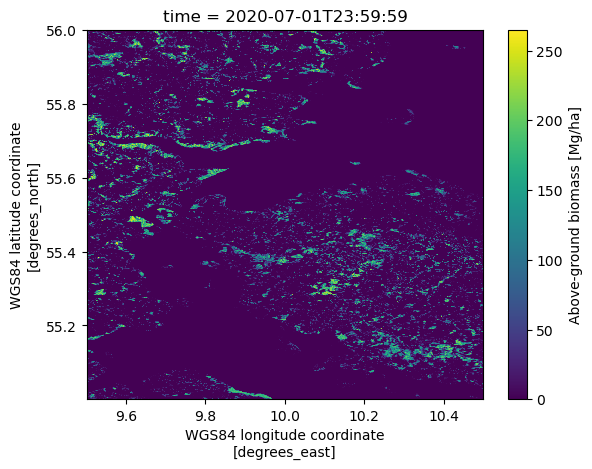

In [26]:
ds.agb.isel(time=0).sel(lat=slice(56, 55), lon=slice(9.5, 10.5)).plot()

In [27]:
storage = new_data_store("file", root="data")

In [28]:
storage.list_data_ids()

['AU-Dry_sen2.zarr',
 'AU-How_era5.zarr',
 'AU-How_sen2.zarr',
 'AU-How_ccibiomass.zarr',
 'AU-Dry_ccibiomass.zarr',
 'AU-Dry_era5.zarr']

In [29]:
ds_ref = storage.open_data("AU-Dry_sen2.zarr")
ds_ref

<xarray.Dataset> Size: 161MB
Dimensions:      (time: 18, y: 400, x: 400)
Coordinates:
  * time         (time) datetime64[ns] 144B 2020-01-02T01:27:09.024000 ... 20...
  * y            (y) float64 3kB 8.312e+06 8.312e+06 ... 8.308e+06 8.308e+06
  * x            (x) float64 3kB 8.601e+05 8.601e+05 ... 8.641e+05 8.641e+05
    spatial_ref  int64 8B ...
Data variables: (12/13)
    B01          (time, y, x) float32 12MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B02          (time, y, x) float32 12MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B03          (time, y, x) float32 12MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B04          (time, y, x) float32 12MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B05          (time, y, x) float32 12MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B06          (time, y, x) float32 12MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    ...           ...
    B08          (time, y, x) float32 12MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B09          (time, y, x) float32 12MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B11          (time, y, x) float32 12MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B12          (time, y, x) float32 12MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B8A          (time, y, x) float32 12MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    SCL          (time, y, x) float64 23MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
Attributes:
    stac_catalog_url:    https://planetarycomputer.microsoft.com/api/stac/v1
    stac_item_id:        S2B_MSIL2A_20200102T012709_R131_T52LHJ_20201002T215923
    stac_item_ids:       {'2020-01-02T01:27:09.024000': ['S2B_MSIL2A_20200102...
    xcube_stac_version:  1.1.2

In [30]:
target_gm = GridMapping.from_dataset(ds_ref)
target_gm

class: **Coords1DGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: _unknown_
* crs: PROJCRS["WGS 84 / UTM zone 52S",BASEGEOGCRS["WGS 84",DATUM["World Geodetic System 1984",ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4326]],CONVERSION["UTM zone 52S",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",129,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["Scale factor at natural origin",0.9996,SCALEUNIT["unity",1],ID["EPSG",8805]],PARAMETER["False easting",500000,LENGTHUNIT["metre",1],ID["EPSG",8806]],PARAMETER["False northing",10000000,LENGTHUNIT["metre",1],ID["EPSG",8807]]],CS[Cartesian,2],AXIS["easting",east,ORDER[1],LENGTHUNIT["metre",1]],AXIS["northing",north,ORDER[2],LENGTHUNIT["metre",1]],ID["EPSG",32752]]
* xy_res: (10, 10)
* xy_bbox: (860110, 8308240, 864110, 8312240)
* ij_bbox: (0, 0, 400, 400)
* xy_dim_names: ('x', 'y')
* xy_var_names: ('x', 'y')
* size: (400, 400)
* tile_size: (400, 400)

In [31]:
ds_rs = resample_in_space(ds, target_gm=target_gm)
ds_rs

<xarray.Dataset> Size: 12MB
Dimensions:      (lat: 157500, nv: 2, lon: 405000, time: 1, bnds: 2, x: 400,
                  y: 400)
Coordinates:
    lat_bnds     (lat, nv) float64 3MB dask.array<chunksize=(157500, 2), meta=np.ndarray>
    lon_bnds     (lon, nv) float64 6MB dask.array<chunksize=(202500, 1), meta=np.ndarray>
  * time         (time) datetime64[ns] 8B 2020-07-01T23:59:59
    time_bnds    (time, bnds) datetime64[ns] 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
  * x            (x) float64 3kB 8.601e+05 8.601e+05 ... 8.641e+05 8.641e+05
  * y            (y) float64 3kB 8.312e+06 8.312e+06 ... 8.308e+06 8.308e+06
    spatial_ref  int64 8B 0
Dimensions without coordinates: lat, nv, lon, bnds
Data variables:
    agb          (time, y, x) float64 1MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    agb_sd       (time, y, x) float64 1MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    title:                   esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-plat...
    date_created:            2026-02-11T13:41:36.067972
    processing_level:        L4
    time_coverage_start:     2020-01-01T00:00:00
    time_coverage_end:       2020-12-31T23:59:59
    time_coverage_duration:  P365DT23H59M59S
    history:                 [{'program': 'xcube_cci.chunkstore.CciChunkStore...

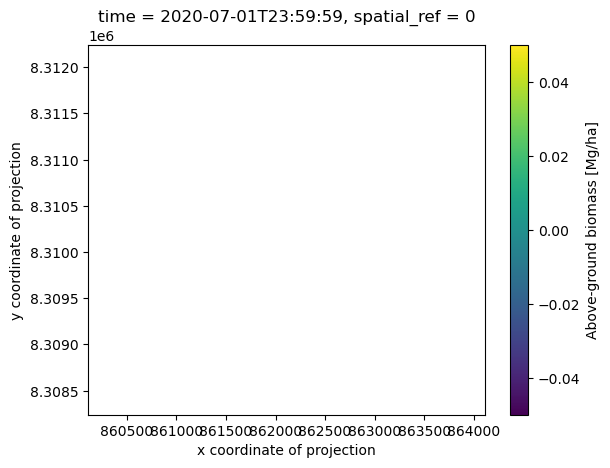

In [32]:
ds_rs.agb.isel(time=0).plot()